In [1]:
# Colab setup: install packages not preinstalled on Colab (safe to re-run)
!pip install -q shap

/bin/bash: pip: command not found


# Reproduce-then-Extend — Snake Habitat Selection (Ecology)  ·  **Day 2 tutorial**

> **Published study.** Multiscale spatial model of snake habitat selection, *PLoS ONE*
> (doi:10.1371/journal.pone.0123307; S1 Dataset, open). A **logistic resource-selection function** — *used*
> (1) vs *available* (0) locations (n = 2075) on canopy cover, shrub cover, aspect, elevation and ground
> cover. Use-vs-availability is the ecology workhorse design → scored by **AUC-PR**.

## Background

Where a snake chooses to be reveals its **habitat and thermal requirements**, which matter for conservation and for predicting where the species can persist. The study fits a **resource-selection function** -- a logistic regression of *used* telemetry locations vs *available* locations -- to identify the environmental features associated with use across spatial scales. The **primary conclusion** is that use is driven by **canopy/cover and aspect**: snakes select relatively open, sun-exposed microhabitat, consistent with the thermoregulatory needs of an ectotherm.

## Data and codebook

**Unit of analysis:** a sampled location -- a telemetry-**used** location vs an **available** location; n = 2,075.

| Variable | Definition |
|---|---|
| `Response` | 1 = used location, 0 = available location **(outcome)** |
| `CanCov` | canopy cover (%) |
| `ShrubCov` | shrub cover (%) |
| `Aspect` | slope aspect (compass orientation / index) |
| `Elevation` | elevation |
| `Cover.` | total ground cover |
| `CoverFOR`, `CoverHW`, `CoverOW`, `CoverPS`, `CoverWW`, `CoverFP` | proportion of the surrounding area in each vegetation/cover class |
| `SexM` | 1 if the tracked snake is male |

## Descriptive results

In [2]:
# Setup: data handling, the published regression (statsmodels), and the ML learners
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.api as sm                     # regression with a full coefficient table
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import average_precision_score   # AUC-PR
import xgboost as xgb                             # gradient boosting
import shap                                       # exact TreeSHAP explanations

In [3]:
d = pd.read_csv('https://raw.githubusercontent.com/desmarais-lab/desmarais-lab.github.io/master/istanbul_bilgi_ml_files/data/snake_clean.csv')
preds = [c for c in d.columns if c != 'Response' and d[c].nunique() > 1]

X, y = d[preds].values, d['Response'].values
print(f'n = {len(d)},  predictors = {len(preds)},  positives = {int(y.sum())}')
d[['Response'] + preds].describe().T[['mean','std','min','max']].round(2)

n = 2075,  predictors = 12,  positives = 282


,mean,std,min,max
Response,0.14,0.34,0.00,1.00
CanCov,0.30,0.22,0.00,1.36
ShrubCov,0.03,0.04,0.00,0.43
Aspect,2.95,0.42,0.73,3.41
Elevation,-27.46,3.10,-32.64,-20.79
Cover.,0.01,0.07,0.00,1.00
CoverFOR,0.21,0.41,0.00,1.00
CoverFP,0.04,0.20,0.00,1.00
CoverHW,0.16,0.37,0.00,1.00
CoverOW,0.02,0.14,0.00,1.00


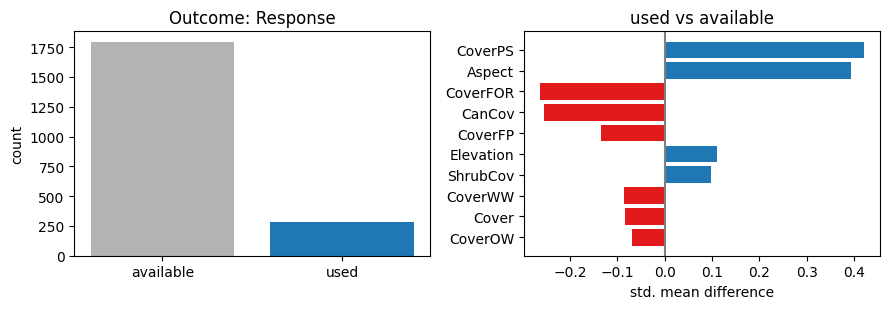

In [4]:
clean = lambda v: [s.replace('_',' ').replace('..',' ').replace('.',' ').strip() for s in v]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
ax[0].bar(['available','used'], np.bincount(y), color=['0.7','#1f78b4']); ax[0].set_title('Outcome: Response'); ax[0].set_ylabel('count')
# standardized mean difference (positive - negative) per predictor
smd = pd.Series({c: (d[c][y==1].mean() - d[c][y==0].mean())/d[c].std() for c in preds})
smd = smd.reindex(smd.abs().sort_values().index)[-10:]
ax[1].barh(clean(smd.index), smd.values, color=['#e31a1c' if v<0 else '#1f78b4' for v in smd])
ax[1].set_title('used vs available'); ax[1].set_xlabel('std. mean difference'); ax[1].axvline(0, color='0.5')
plt.tight_layout(); plt.show()

## Reproduce the published RSF regression

In [5]:
rsf = sm.Logit(y, sm.add_constant(d[preds])).fit(disp=False)
print(rsf.summary())

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 2075
Model:                          Logit   Df Residuals:                     2063
Method:                           MLE   Df Model:                           11
Date:                Thu, 02 Jul 2026   Pseudo R-squ.:                 0.07110
Time:                        12:57:04   Log-Likelihood:                -766.09
converged:                      False   LL-Null:                       -824.72
Covariance Type:            nonrobust   LLR p-value:                 6.420e-20
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -8.2561   1.57e+06  -5.25e-06      1.000   -3.08e+06    3.08e+06
CanCov        -1.3218      0.410     -3.226      0.001      -2.125      -0.519
ShrubCov       3.9155      1.544      2.537      0.0

/Users/bbd5087/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


**Confirmation against the published study.** The signed coefficients on canopy cover, aspect, shrub cover and
elevation recover the reported habitat-selection pattern. This logistic RSF is our regression baseline.

We evaluate honestly: split off a **stratified 30% test set**, tune each learner's hyperparameters by cross-validation on the **training set only**, then score each model **once on the untouched test set** by AUC-PR (the right metric for this rare outcome).

In [6]:
# Honest out-of-sample evaluation: hold out a test set, tune on the training set, score once on test
from sklearn.model_selection import train_test_split
tr_idx, te_idx = train_test_split(np.arange(len(y)), test_size=0.30, stratify=y, random_state=2026)
Xtr, Xte, ytr, yte = X[tr_idx], X[te_idx], y[tr_idx], y[te_idx]
test_ap = {}

# 1. logistic regression -- the published model (no hyperparameters)
lr = LogisticRegression(penalty=None, max_iter=2000).fit(Xtr, ytr)
test_ap['Logit'] = average_precision_score(yte, lr.predict_proba(Xte)[:, 1])

# 2. random forest -- max_features tuned on the TRAINING set by out-of-bag AUC-PR
best_rf = None
for mf in ['sqrt', 0.33, 0.5]:
    rf = RandomForestClassifier(n_estimators=600, max_features=mf, oob_score=True,
                                bootstrap=True, random_state=0, n_jobs=-1).fit(Xtr, ytr)
    oob_ap = average_precision_score(ytr, rf.oob_decision_function_[:, 1])
    if best_rf is None or oob_ap > best_rf[0]: best_rf = (oob_ap, mf)
rf = RandomForestClassifier(n_estimators=600, max_features=best_rf[1], random_state=0, n_jobs=-1).fit(Xtr, ytr)
test_ap['RandomForest'] = average_precision_score(yte, rf.predict_proba(Xte)[:, 1])

# 3. XGBoost -- depth x eta tuned by xgb.cv on the TRAINING set; nrounds via early stopping
dtr = xgb.DMatrix(Xtr, label=ytr); best = None
for depth in [3, 4, 6]:
    for eta in [0.05, 0.1]:
        r = xgb.cv({'objective': 'binary:logistic', 'max_depth': depth, 'eta': eta,
                    'subsample': 0.9, 'colsample_bytree': 0.8, 'eval_metric': 'aucpr'},
                   dtr, num_boost_round=500, nfold=5, early_stopping_rounds=25, seed=0)
        s = r['test-aucpr-mean'].max()
        if best is None or s > best[0]: best = (s, depth, eta, len(r))
bst = xgb.train({'objective': 'binary:logistic', 'max_depth': best[1], 'eta': best[2],
                 'subsample': 0.9, 'colsample_bytree': 0.8}, dtr, num_boost_round=best[3])
test_ap['XGBoost'] = average_precision_score(yte, bst.predict(xgb.DMatrix(Xte)))

print({m: round(v, 3) for m, v in test_ap.items()})
print(f"Best-ML gain over the logit on the held-out test set: "
      f"+{max(test_ap['RandomForest'], test_ap['XGBoost']) - test_ap['Logit']:.3f} AUC-PR")


{'Logit': np.float64(0.249), 'RandomForest': np.float64(0.615), 'XGBoost': np.float64(0.58)}
Best-ML gain over the logit on the held-out test set: +0.366 AUC-PR


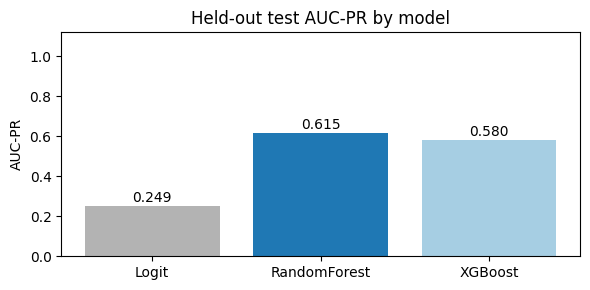

In [7]:
best_ml = 'RandomForest' if test_ap['RandomForest'] >= test_ap['XGBoost'] else 'XGBoost'
cols = ['0.7'] + ['#a6cee3'] * 2
cols[['Logit', 'RandomForest', 'XGBoost'].index(best_ml)] = '#1f78b4'
plt.figure(figsize=(6, 3)); bars = plt.bar(list(test_ap), list(test_ap.values()), color=cols)
plt.ylim(0, 1.12); plt.ylabel('AUC-PR'); plt.title('Held-out test AUC-PR by model')
for b, v in zip(bars, test_ap.values()): plt.text(b.get_x() + b.get_width() / 2, v + .02, f'{v:.3f}', ha='center')
plt.tight_layout(); plt.show()


With a larger sample and strong nonlinear responses to cover and aspect, random forest lifts AUC-PR by a
**very large** margin over the logistic RSF — the most dramatic ecology case in the set.

## Interpreting the model: importance, SHAP, and partial dependence

In [8]:
rf = RandomForestClassifier(n_estimators=500, random_state=0, n_jobs=-1).fit(X, y)
bst = xgb.train({'objective': 'binary:logistic', 'max_depth': 4, 'eta': 0.05,
                'subsample': 0.9, 'colsample_bytree': 0.8}, xgb.DMatrix(X, label=y), num_boost_round=300)
shap_values = shap.TreeExplainer(bst).shap_values(X)   # signed per-observation contributions (log-odds)

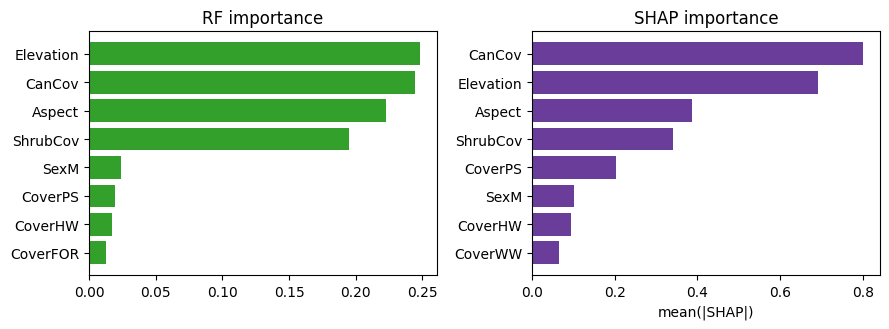

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
imp_rf = pd.Series(rf.feature_importances_, index=preds).sort_values()[-8:]
ax[0].barh(clean(imp_rf.index), imp_rf.values, color='#33a02c'); ax[0].set_title('RF importance')
imp_sh = pd.Series(np.abs(shap_values).mean(0), index=preds).sort_values()[-8:]
ax[1].barh(clean(imp_sh.index), imp_sh.values, color='#6a3d9a'); ax[1].set_title('SHAP importance'); ax[1].set_xlabel('mean(|SHAP|)')
plt.tight_layout(); plt.show()

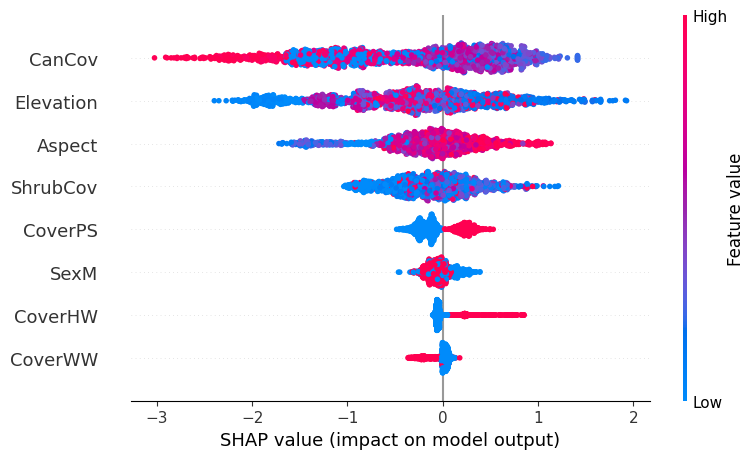

In [10]:
# SHAP summary (beeswarm): each point an observation, coloured by feature value
shap.summary_plot(shap_values, d[preds], feature_names=clean(preds), show=False, max_display=8)
plt.tight_layout(); plt.show()

**Interpreting the relationships.** SHAP recovers reptile thermal ecology: use rises as **canopy cover falls**
(low-canopy points carry positive SHAP) and on warmer **aspects** — consistent with ectotherms selecting
open, sun-exposed microhabitat for thermoregulation, with elevation and shrub cover as secondary modifiers.

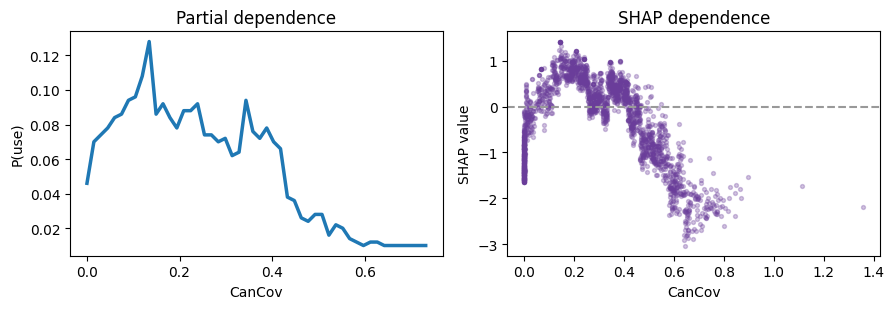

In [11]:
top1 = preds[int(np.abs(shap_values).mean(0).argmax())]
fig, ax = plt.subplots(1, 2, figsize=(9, 3.2))
# partial dependence: vary top1 over its range, hold others at the median
grid = np.linspace(np.quantile(d[top1], .02), np.quantile(d[top1], .98), 50)
base = np.tile(np.median(X, 0), (50, 1)); base[:, preds.index(top1)] = grid
ax[0].plot(grid, rf.predict_proba(base)[:, 1], color='#1f78b4', lw=2.5)
ax[0].set_xlabel(clean([top1])[0]); ax[0].set_ylabel('P(use)'); ax[0].set_title('Partial dependence')
# SHAP dependence: how top1's SHAP contribution varies with its value
j = preds.index(top1)
ax[1].scatter(X[:, j], shap_values[:, j], s=8, alpha=.3, color='#6a3d9a')
ax[1].axhline(0, ls='--', color='0.6'); ax[1].set_xlabel(clean([top1])[0]); ax[1].set_ylabel('SHAP value'); ax[1].set_title('SHAP dependence')
plt.tight_layout(); plt.show()

## Takeaway

Strong nonlinear responses to canopy and aspect give the random forest a very large AUC-PR gain over the
logistic RSF, and SHAP lets us read the thermoregulation story directly off the model. With the Pinyon Jay,
it shows the result is general across taxa.

## Recommended exercises

1. Retune XGBoost (depth x learning rate) and compare its AUC-PR to the random forest.
2. Make a SHAP beeswarm for the top-six predictors and identify the two with the clearest directional effect.
3. Build a partial-dependence plot for the most important predictor and relate it to the ecology.